In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import yfinance as yf

from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.stattools import adfuller

plt.style.use("seaborn-v0_8")


Load Data

In [2]:
ticker = "RELIANCE.NS"

df = yf.download(
    ticker,
    start="2015-01-01",
    end="2025-01-01"
)

df = df[['Close']].dropna()
df.head()


C:\Users\KRISHNENDU\AppData\Local\Temp\ipykernel_7000\3164813451.py:3: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(
[*********************100%***********************]  1 of 1 completed


Price,Close
Ticker,RELIANCE.NS
Date,
2015-01-01,189.999786
2015-01-02,189.496948
2015-01-05,187.421249
2015-01-06,178.915253
2015-01-07,182.809830


Train–Test Split (Time-Based)

In [3]:
train_size = int(len(df) * 0.8)

train = df.iloc[:train_size]
test = df.iloc[train_size:]


Make Series Stationary

In [4]:
train_diff = train['Close'].diff().dropna()


Fit ARIMA Model

In [5]:
model = ARIMA(train['Close'], order=(1,1,1))
model_fit = model.fit()

model_fit.summary()


C:\Users\KRISHNENDU\anaconda3\envs\etl-pipeline\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\KRISHNENDU\anaconda3\envs\etl-pipeline\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\KRISHNENDU\anaconda3\envs\etl-pipeline\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:            RELIANCE.NS   No. Observations:                 1973
Model:                 ARIMA(1, 1, 1)   Log Likelihood               -7747.217
Date:                Sat, 31 Jan 2026   AIC                          15500.433
Time:                        11:20:31   BIC                          15517.194
Sample:                             0   HQIC                         15506.592
                               - 1973                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.2105      0.599      0.352      0.725      -0.963       1.384
ma.L1         -0.1879      0.601     -0.313      0.754      -1.365       0.989
sigma2       151.3061      2.268     66.703      0.000     146.860     155.752
===================================================================================
Ljung-Box (L1) (Q):                   0.03   Jarque-Bera (JB):              4201.45
Prob(Q):                              0.87   Prob(JB):                         0.00
Heteroskedasticity (H):              23.92   Skew:                             0.02
Prob(H) (two-sided):                  0.00   Kurtosis:                        10.15
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

Forecast on Test Period

In [6]:
forecast = model_fit.forecast(steps=len(test))

forecast.index = test.index


C:\Users\KRISHNENDU\anaconda3\envs\etl-pipeline\lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
C:\Users\KRISHNENDU\anaconda3\envs\etl-pipeline\lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


Plot Forecast vs Actual

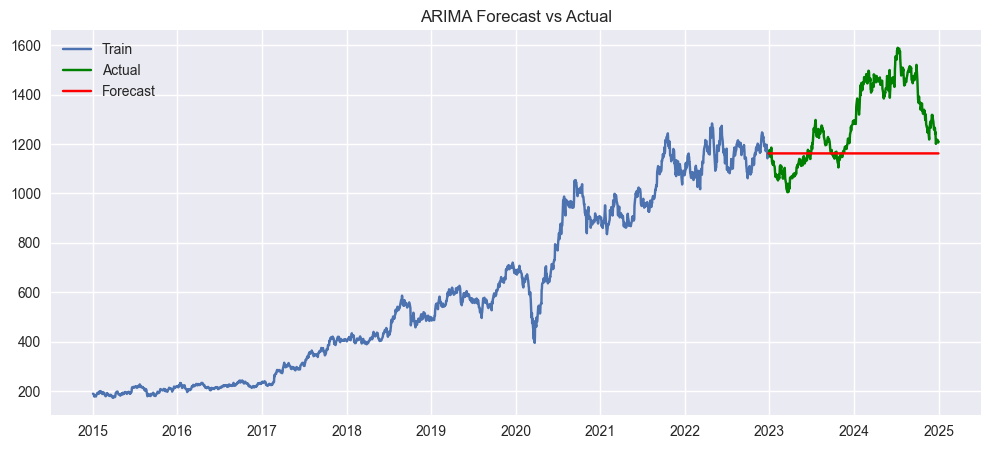

In [7]:
plt.figure(figsize=(12,5))
plt.plot(train['Close'], label='Train')
plt.plot(test['Close'], label='Actual', color='green')
plt.plot(forecast, label='Forecast', color='red')

plt.legend()
plt.title("ARIMA Forecast vs Actual")
plt.show()


Forecast Error (Simple Evaluation)

In [8]:
from sklearn.metrics import mean_absolute_error

mae = mean_absolute_error(test['Close'], forecast)
print("MAE:", mae)


MAE: 153.77457851214388
